# Market Trend Anaylsis - Stock Prices
*   Alexander Gutting, Jaime Espinola, Tsvetelina Hristova, Sinduja Manchi
*   CS 5100 Foundations Artificial Intelligence - Summer 2025
*   August 12th, 2025

The first step in analysis is to import the necessary modules cell imports the necessary modules to preprocess, analyze, evaluate and then visualize the data

In [24]:
import kagglehub
import pandas as pd
import numpy as py
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder

Next we include code to load data. It imports the following 5 year stock dataset and outputs a sample of the unedited data before modification.

In [25]:
# Download the dataset and get the path
path = kagglehub.dataset_download("camnugent/sandp500")
print("Path to dataset files:", path)

# Specify the CSV file we want to use
csv_file = "all_stocks_5yr.csv"

# Full path to the CSV file
csv_file_path = os.path.join(path, csv_file)

# Load the dataset into a pandas DataFrame
df = pd.read_csv(csv_file_path)

# Preview the first few rows of the dataset to make sure it is loading correctly
print(df.head())

Path to dataset files: /Users/alexgutting/.cache/kagglehub/datasets/camnugent/sandp500/versions/4
         date   open   high    low  close    volume Name
0  2013-02-08  15.07  15.12  14.63  14.75   8407500  AAL
1  2013-02-11  14.89  15.01  14.26  14.46   8882000  AAL
2  2013-02-12  14.45  14.51  14.10  14.27   8126000  AAL
3  2013-02-13  14.30  14.94  14.25  14.66  10259500  AAL
4  2013-02-14  14.94  14.96  13.16  13.99  31879900  AAL


Next we explore the dataset and check for missing values.

In [26]:
# Preview the last few rows
df.tail()

,date,open,high,low,close,volume,Name
619035,2018-02-01,76.84,78.27,76.69,77.82,2982259,ZTS
619036,2018-02-02,77.53,78.12,76.73,76.78,2595187,ZTS
619037,2018-02-05,76.64,76.92,73.18,73.83,2962031,ZTS
619038,2018-02-06,72.74,74.56,72.13,73.27,4924323,ZTS
619039,2018-02-07,72.70,75.00,72.69,73.86,4534912,ZTS


Then output the dimensions of the dataframe, print the dataframe information to get an understanding of the column names. We also check for missing values and drop them.

In [27]:
df.shape

(619040, 7)

In [28]:
#Print out the dataframe information to see all the column names and datatypes, and dataset size
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 619040 entries, 0 to 619039
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    619040 non-null  object 
 1   open    619029 non-null  float64
 2   high    619032 non-null  float64
 3   low     619032 non-null  float64
 4   close   619040 non-null  float64
 5   volume  619040 non-null  int64  
 6   Name    619040 non-null  object 
dtypes: float64(4), int64(1), object(2)
memory usage: 33.1+ MB


In [29]:
#Check the size of the dataset
df.shape

(619040, 7)

In [30]:
#Check how many missing values there are per column
df.isnull().sum()

date       0
open      11
high       8
low        8
close      0
volume     0
Name       0
dtype: int64

In [31]:
#There are a few missing values for the open, high, and low column. We will drop these records
df.dropna(inplace=True)

In [32]:
#Check to make sure there are no more missing/null values in the dataset
df.isnull().sum()

date      0
open      0
high      0
low       0
close     0
volume    0
Name      0
dtype: int64

Then we search for any missing values in the dataframe and output the sum of those missing values (if any) as well as a sample of the revised dataframe.

In [33]:
df.isna().sum()
df

,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL
...,...,...,...,...,...,...,...
619035,2018-02-01,76.84,78.27,76.69,77.82,2982259,ZTS
619036,2018-02-02,77.53,78.12,76.73,76.78,2595187,ZTS
619037,2018-02-05,76.64,76.92,73.18,73.83,2962031,ZTS
619038,2018-02-06,72.74,74.56,72.13,73.27,4924323,ZTS


Then we eliminate all duplicates in the dataframe and output a sample of the revised dataframe once again.

In [34]:
df.duplicated().sum()
df.drop_duplicates()
df

,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL
...,...,...,...,...,...,...,...
619035,2018-02-01,76.84,78.27,76.69,77.82,2982259,ZTS
619036,2018-02-02,77.53,78.12,76.73,76.78,2595187,ZTS
619037,2018-02-05,76.64,76.92,73.18,73.83,2962031,ZTS
619038,2018-02-06,72.74,74.56,72.13,73.27,4924323,ZTS


Next we Encode String Name column to be Numeric.

In [35]:
# Encode the 'Name' column into numeric values
label_encoder = LabelEncoder()
df['Name_numeric'] = label_encoder.fit_transform(df['Name'])

Then we check two examples of target values in the dataset.

In [36]:
stock_ex_one = df['close'][20]
stock_ex_one

np.float64(15.13)

In [37]:
stock_ex_two = df['close'][50]
stock_ex_two

np.float64(16.3)

Next we group the columns as Features or Targets

In [38]:
#Labeling the columns as features, and the target column closed price as the target
features = ['open', 'high', 'low', 'volume', 'Name_numeric']
target = 'close'

Then we create a Linear Regression Model.



In [39]:
X = df[features]
y = df[target]

#Split the data into training and testing data sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Create a linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Then we evaluate the performance of the linear regression model. A mean squared error (MSE) score is the average of the squared differences between the actual and predicted results. A lower value indicates a better fit because it shows the actual values are closer to the predicted values. The value of 0.4697 indicates a good fit. The r2 score measures how well the model explains the variability of the target variable. A value of 1 would indicate that the model predicts the data perfectly. Our value is very close to 1, showing a good fit. The mean absolute error (MAE) measures the absolute difference between the actual values and the predicted values from the model. In general, a smaller MAE is better. The MAE value indicates by how many units off are the predictions. In our case this would mean we are off by 0.32 cents, which is pretty good.

In [40]:
# Defines a test prediction variable that will be used for the predictions of all three metrics and outputs those predictions
y_pred = model.predict(X_test).ravel()
print(f"MSE = {mean_squared_error(y_test, y_pred):.2f}")
print(f"R^2 = {r2_score(y_test, y_pred):.2f}")
print(f"MAE = {mean_absolute_error(y_test, y_pred):.2f}")

MSE = 0.47
R^2 = 1.00
MAE = 0.34


Then we plot the actual versus predicted data. In the graph, you can see a very good fit between the actual and the predicted because both follow along the same line.

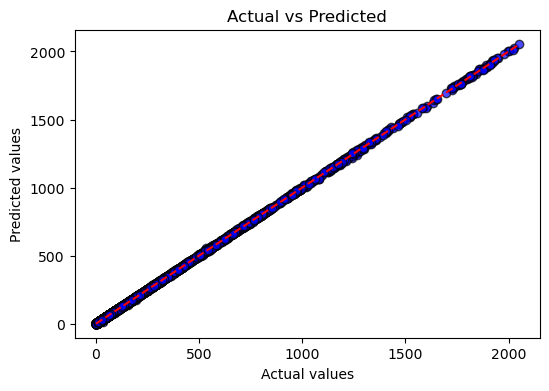

In [41]:
# Plot Actual vs Predicted
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, color='blue', edgecolor='black', alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.title('Actual vs Predicted')
plt.xlabel('Actual values')
plt.ylabel('Predicted values')
plt.show()

Then we plot the residuals. In a residual plot, you want to see a random but evenly scattered pattern of points around the horizontal axis - this shows that the errors are random and that there is no major bias. AS you can see below, the plot looks good.

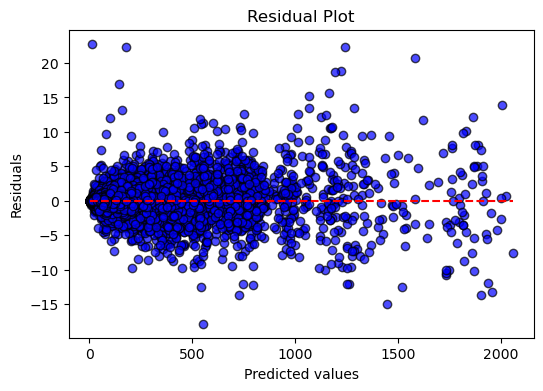

In [42]:
# Calculate residuals
residuals = y_test - y_pred

# Plot Residuals
plt.figure(figsize=(6, 4))
plt.scatter(y_pred, residuals, color='blue', edgecolor='black', alpha=0.7)
plt.hlines(y=0, xmin=min(y_pred), xmax=max(y_pred), color='red', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.show()

Then we plot the prediction distribution plot. This plots both the predicted and actual values. In a good fit, the two plots overlay each other almost completely to indicate a close match. You can see below that the two plots are very closely matched and therefore the model is a good fit.

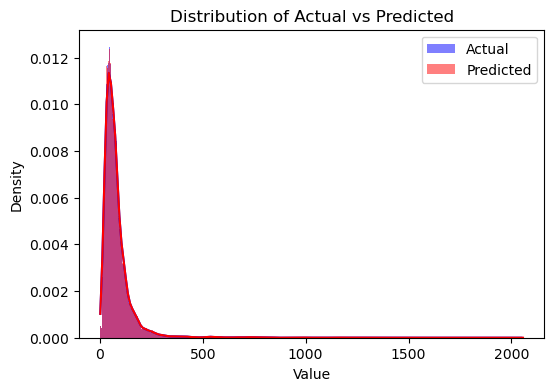

In [43]:
# Plot distribution of Actual and Predicted values
plt.figure(figsize=(6, 4))
sns.histplot(y_test, color='blue', label='Actual', kde=True, stat='density', linewidth=0)
sns.histplot(y_pred, color='red', label='Predicted', kde=True, stat='density', linewidth=0)
plt.title('Distribution of Actual vs Predicted')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.show()

Next we creates five linear regression lines of data in different plot distribution graphs. In each of the five plots below, we are showing the relationship between a feature (such as open price, high price, low price, volume, or name) ahd the close price. Based on the plots below, we know that the open, high, and low prices are good predictors of the close price. Higher open, high, and low prices indicate a higher close price. The correlation between the volume and close price indicates that most stocks have a low volume and a low price. This skews the data and makes it difficult to establish a strong correlation between volume and close price. Finally, the name graph shows that there is no correlation between name and closing price. This makes sense because the closing price is not related to the name of the stock.

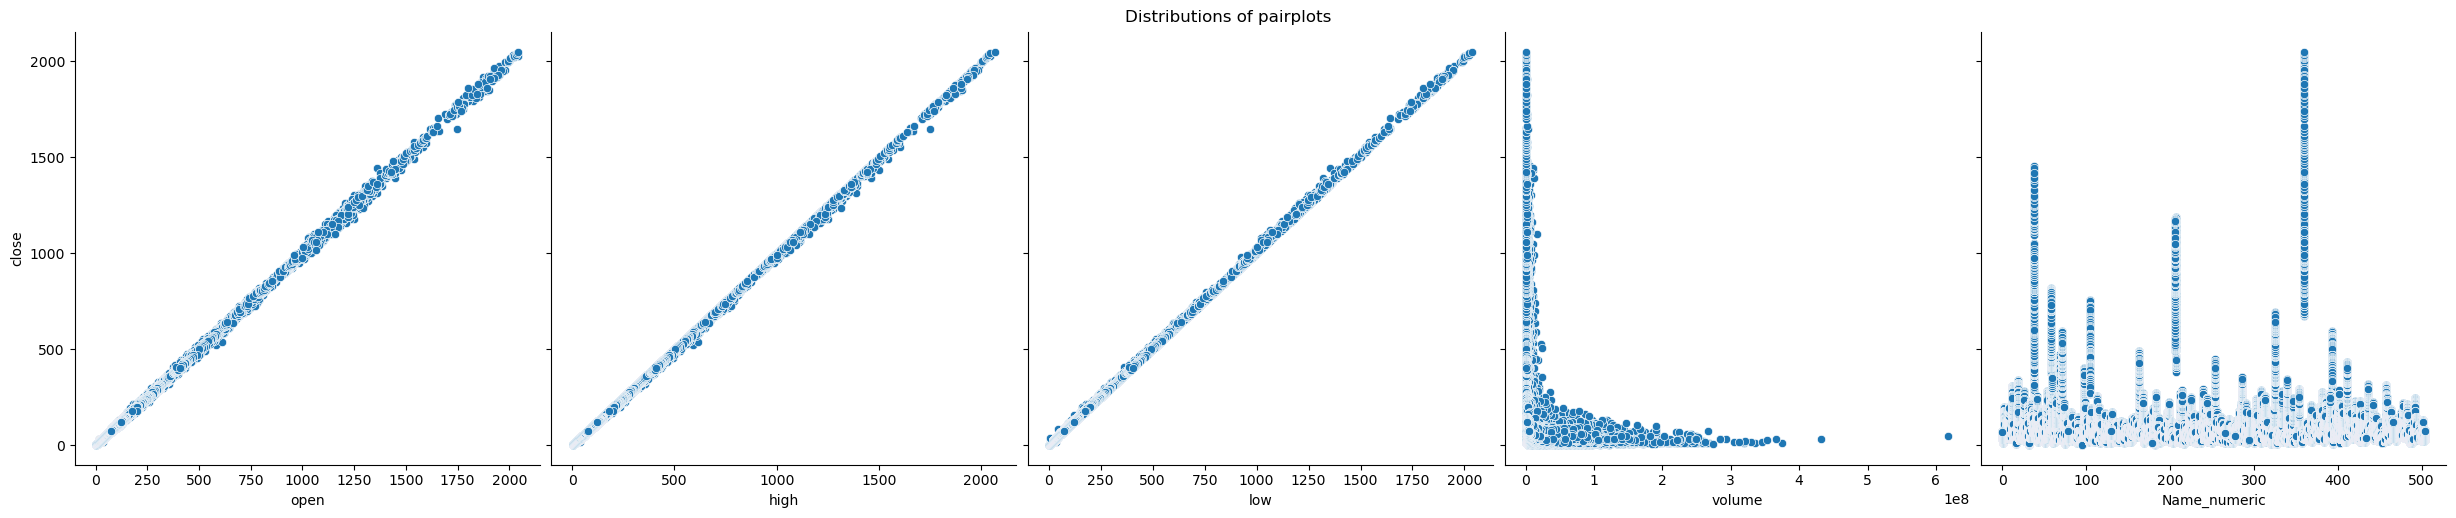

In [44]:
# Plot distribution of a pairplot graph that compares the feature variable data with the target variable data
sns.pairplot(df, x_vars=['open', 'high', 'low', 'volume', 'Name_numeric'], y_vars=['close'], kind='scatter', height=5, aspect=1)
plt.suptitle('Distributions of pairplots', y=1.02)
plt.show()

Lastly, we create a dataframe that summarizes the actual closing price versus the predicted price for various stocks. It is a nice visual to show how well the model is working to predict the prices. As you can see, most of the price differences are off by less than 50 cents.

In [45]:
# Create a DataFrame showing Actual vs Predicted Close Prices (first 10 examples)
example_outputs = pd.DataFrame({
    'Actual Close Price': y_test.values[:10],
    'Predicted Close Price': y_pred[:10]
})

# Add an absolute difference column
example_outputs['Difference'] = abs(example_outputs['Actual Close Price'] - example_outputs['Predicted Close Price'])

# Round values for neat presentation
example_outputs_rounded = example_outputs.round(2)

# Display the table
print("Example Outputs (first 10 predictions):")
print(example_outputs_rounded)

Example Outputs (first 10 predictions):
   Actual Close Price  Predicted Close Price  Difference
0              117.06                 117.30        0.24
1              101.62                 100.95        0.67
2              126.54                 126.71        0.17
3               89.03                  89.34        0.31
4               53.51                  53.28        0.23
5              156.78                 156.74        0.04
6              175.97                 176.55        0.58
7               18.18                  18.19        0.01
8               61.78                  61.53        0.25
9              179.97                 180.04        0.07
